The objective of this project is to classify breast tumors as Malignant or Benign using Machine Learning algorithms.We make use of algorithms such as Support vector machine,k nearest neighbours and evaluate the results.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [45]:
df = pd.read_csv('/content/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The columns are displayed above. We can see that there is a a categorical column and rest are numerical columns.id and un_named32 columns are not necessary for the analysis so we can drop them. The categorical column need to be encoded into numerical values.

In [47]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [48]:
#Data Preprocessing
#removing unnecessary columns
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [49]:
#encoding
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [50]:
#features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [51]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,)
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [52]:
#feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature selection is the process of choosing only the most useful input features for a machine learning model. It helps improve model performance, reduces noise and makes results easier to understand.

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It tries to find the best boundary known as hyperplane that separates different classes in the data.

In [53]:
#Support Vector Machine
#linear kernal
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)
print("Accuracy:", acc_linear)
cm_linear = confusion_matrix(y_test, y_pred_linear)
print(cm_linear)

Accuracy: 0.956140350877193
[[68  3]
 [ 2 41]]


linear kernal is used for linear separability

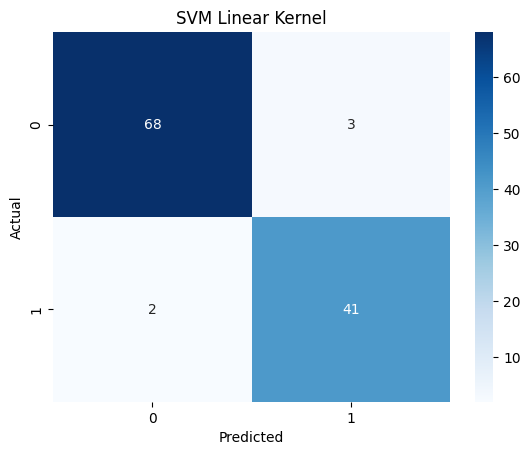

In [54]:
sns.heatmap(cm_linear,annot=True,fmt='d',cmap='Blues')
plt.title("SVM Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
#RBF Kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print("Accuracy:", acc_rbf)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print(cm_rbf)

Accuracy: 0.9824561403508771
[[71  0]
 [ 2 41]]


The radial basis function kernal transforms data into a space based on distances between data points.

In [56]:
#Sigmoid Kernel
svm_sigmoid = SVC(kernel='sigmoid')
svm_sigmoid.fit(X_train, y_train)
y_pred_sigmoid = svm_sigmoid.predict(X_test)
acc_sigmoid = accuracy_score(y_test, y_pred_sigmoid)
print("Accuracy:", acc_sigmoid)
cm_sigmoid = confusion_matrix(y_test, y_pred_sigmoid)
print(cm_sigmoid)

Accuracy: 0.956140350877193
[[68  3]
 [ 2 41]]


The Sigmoid Kernel in Support Vector Machines (SVMs) is a mathematical function that calculates similarity by mimicking the behavior of an artificial neural network activation function

In [57]:
#Polynomial Kernel
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, y_pred_poly)
print("Accuracy:", acc_poly)
cm_poly = confusion_matrix(y_test, y_pred_poly)
print(cm_poly)

Accuracy: 0.868421052631579
[[71  0]
 [15 28]]


The polynomial kernel is a popular kernel function used in Support Vector Machines (SVMs) to learn non-linear decision boundaries by implicitly mapping data into a higher-dimensional feature space. It allows the model to look at combinations and interactions of existing features without experiencing the computational explosion of actually calculating those higher-dimensional coordinates.

In [58]:
#KNN
#elbow method
error_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error = np.mean(pred_k != y_test)
    error_rate.append(error)

Knn is an algorithm that takes into consideration k nearest neighbours and use that data in its machine learning algorithm.

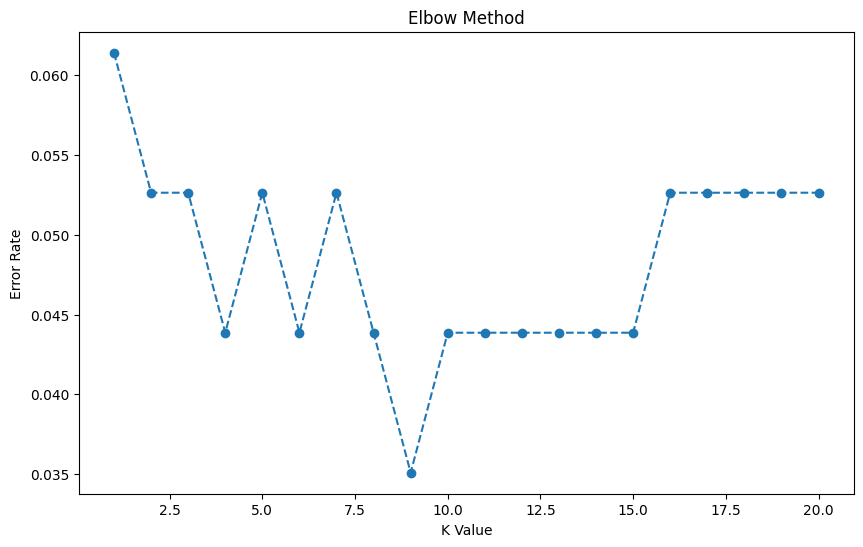

In [59]:
#Elbow Graph
plt.figure(figsize=(10,6))
plt.plot(range(1,21),error_rate,marker='o',linestyle='--')
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Elbow Method")
plt.show()

The elbow graph is used to find teh best k value. The sharp elbow point in the graph is choosen as the best k value to be used in knn algorithm.

In [60]:
optimal_k = 9
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", acc_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

Accuracy: 0.9649122807017544
[[69  2]
 [ 2 41]]


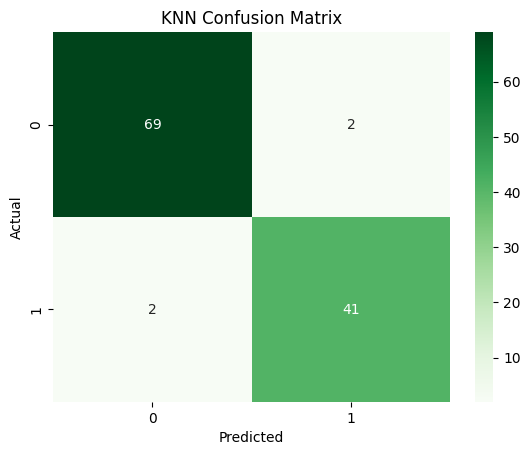

In [61]:
#knn confusion matrix
sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
#accuracy comparison
results = pd.DataFrame({
    'Model': ['SVM Linear','SVM RBF','SVM Sigmoid','SVM Polynomial','KNN' ],
    'Accuracy': [acc_linear,acc_rbf,acc_sigmoid,acc_poly,acc_knn]
})
results.sort_values(by='Accuracy',
                    ascending=False)

,Model,Accuracy
1,SVM RBF,0.982456
4,KNN,0.964912
0,SVM Linear,0.956140
2,SVM Sigmoid,0.956140
3,SVM Polynomial,0.868421


Here we can say that the svm rbf model is the most accurate and the polynomial model is the least accurate. This trained model can be later used to classify the breast cancer when the values of its features are given. Higher accuracy is necessary for the classification done in healthcare feild.